# European contract pricing with Tree

In [2]:
import numpy as np
from scipy.optimize import minimize
from collections.abc import Callable

## Create European contract payoff

In [3]:
def european_call_payoff(S: float, K: float) -> float:
    return max(S-K, 0.0)

## Create Spot Tree

In [4]:
def create_spot_tree(spot: float, spot_mult_up: float, spot_mult_down: float, steps: int) -> list[list[float]]:
    previous_level = [spot]
    tree = [previous_level]
    for _ in range(steps):
        new_level = [s * spot_mult_down for s in previous_level]
        new_level += [previous_level[-1] * spot_mult_up]
        tree += [new_level]
        previous_level = new_level
    return tree

In [5]:
spot = 1
spot_mult_up = 1.2
spot_mult_down = 0.8
steps = 2
spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down, steps)
spot_tree_readable = [['%.3f' % e for e in n] for n in spot_tree]
spot_tree_readable

[['1.000'], ['0.800', '1.200'], ['0.640', '0.960', '1.440']]

## Create Price Tree

In [6]:
def create_discounted_price_tree(spot_tree: list[list[float]], discount_factor: float, K: float, diag: int = 0) -> list[list[float]]:
    spot = spot_tree[0][0]
    spot_mult_up = spot_tree[1][-1]
    spot_mult_down = spot_tree[1][0]
    p_up = ((1 / discount_factor - spot_mult_down) /
                   (spot_mult_up - spot_mult_down))
    p_down = 1 - p_up
    steps = len(spot_tree) - 1
    continuation_value_tree = [[np.nan for _ in level] for level in spot_tree]
    if diag > 0:
        print("risk-neutral measure: ")
        print(('%.3f' % p_up, '%.3f' % p_down))
        # init delta tree
        delta_tree = [[np.nan for _ in level] for level in spot_tree[:-1]] #delta makes no sense for leaves
    # going backwards, payoff is known in leaves
    for i in range(len(spot_tree[-1])):
        spot = spot_tree[-1][i]
        discounted_continuation_value = discount_factor**(steps) * european_call_payoff(spot, K)
        continuation_value_tree[-1][i] = discounted_continuation_value
    for step in range(steps - 1, -1, -1):
        for i in range(len(spot_tree[step])):
            continuation_value_tree[step][i] = p_up * continuation_value_tree[step + 1][i] + \
                                            p_down * continuation_value_tree[step + 1][i + 1]
            if diag > 0:
                delta_tree[step][i] = ((continuation_value_tree[step + 1][i] - continuation_value_tree[step + 1][i + 1]) 
                                       / (spot_tree[step + 1][i] - spot_tree[step + 1][i + 1]))
    if diag > 0:
        print("delta: ")
        delta_tree_readable = [['%.3f' % e for e in n] for n in delta_tree]
        print(delta_tree_readable)
    return continuation_value_tree

In [7]:
discount_factor = 0.95
strike = 1
diag = 1
price_tree = create_discounted_price_tree(spot_tree, discount_factor, strike, diag)
price_tree_readable = [['%.3f' % e for e in n] for n in price_tree]
print("Price tree:")
price_tree_readable


risk-neutral measure: 
('0.632', '0.368')
delta: 
[['0.366'], ['-0.000', '0.827']]
Price tree:


[['0.054'], ['0.000', '0.146'], ['0.000', '0.000', '0.397']]

In [8]:
pv_up_up = 0.44*0.95*0.95
print('%.3f' % pv_up_up)

0.397


In [9]:
mid_step = 0.3971 * 0.3684210526315791
print('%.3f' % mid_step)

0.146


## Balanced Tree

In [10]:
def calcBalancedDownStep(spot_mult_up: float, discount_factor: float) -> (float, float):
    return spot_mult_up - 2 * (spot_mult_up - 1 / discount_factor)

In [11]:
print("spot_mult_up: " + str('%.3f' %spot_mult_up))
spot_mult_down_balanced = calcBalancedDownStep(spot_mult_up, discount_factor)
print("spot_mult_down: " + str('%.3f' %spot_mult_down_balanced))
spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down_balanced, steps)
spot_tree_readable = [['%.3f' % e for e in n] for n in spot_tree]
print("spot_tree: " + str(spot_tree_readable))
price_tree = create_discounted_price_tree(spot_tree, discount_factor, strike, 1)
price_tree_readable = [['%.3f' % e for e in n] for n in price_tree]
print("price tree: " + str(price_tree_readable))

spot_mult_up: 1.200
spot_mult_down: 0.905
spot_tree: [['1.000'], ['0.905', '1.200'], ['0.820', '1.086', '1.440']]
risk-neutral measure: 
('0.500', '0.500')
delta: 
[['0.674'], ['0.292', '0.903']]
price tree: [['0.138'], ['0.039', '0.237'], ['0.000', '0.078', '0.397']]


## Delta is close to 0.5 for At The Money Forward option

In [12]:
strike_ATMF = 1/0.95**2
price_tree = create_discounted_price_tree(spot_tree, discount_factor, strike_ATMF, 1)
price_tree_readable = [['%.3f' % e for e in n] for n in price_tree]
print("price tree:")
price_tree_readable

risk-neutral measure: 
('0.500', '0.500')
delta: 
[['0.508'], ['-0.000', '0.847']]
price tree:


[['0.075'], ['0.000', '0.150'], ['0.000', '0.000', '0.300']]

## Barrier options

In [13]:
def up_and_out(B: float) -> Callable[[float], float]:
    def knock_multiplier(s: float) -> float:
        return 1.0 if (s < B) else 0.0
    return knock_multiplier

In [14]:
def create_discounted_price_tree_ko(spot_tree: list[list[float]], discount_factor: float, K: float, ko_function: Callable[[float], float], diag: int = 0) -> list[list[float]]:
    spot = spot_tree[0][0]
    spot_mult_up = spot_tree[1][-1]
    spot_mult_down = spot_tree[1][0]
    p_up = ((1 / discount_factor - spot_mult_down) /
                   (spot_mult_up - spot_mult_down))
    p_down = 1 - p_up
    steps = len(spot_tree) - 1
    continuation_value_tree = [[np.nan for _ in level] for level in spot_tree]
    if diag > 0:
        print("risk-neutral measure: ")
        print((p_up, p_down))
        # init delta tree
        delta_tree = [[np.nan for _ in level] for level in spot_tree[:-1]] #delta makes no sense for leaves
    # going backwards, payoff is known in leaves
    for i in range(len(spot_tree[-1])):
        spot = spot_tree[-1][i]
        discounted_continuation_value = discount_factor**(steps) * european_call_payoff(spot, K) * ko_function(spot)
        continuation_value_tree[-1][i] = discounted_continuation_value
    for step in range(steps - 1, -1, -1):
        for i in range(len(spot_tree[step])):
            continuation_value_tree[step][i] = p_up * continuation_value_tree[step + 1][i] + \
                                            p_down * continuation_value_tree[step + 1][i + 1]
            continuation_value_tree[step][i] *= ko_function(spot_tree[step][i])
            if diag > 0:
                delta_tree[step][i] = ((continuation_value_tree[step + 1][i] - continuation_value_tree[step + 1][i + 1]) 
                                       / (spot_tree[step + 1][i] - spot_tree[step + 1][i + 1]))
                delta_tree[step][i] *= ko_function(spot_tree[step][i])
    if diag > 0:
        print("delta: ")
        delta_tree_readable = [['%.3f' % e for e in n] for n in delta_tree]
        print(delta_tree_readable)
    return continuation_value_tree

In [15]:
# create spot tree
spot = 1
maturity = 1 # years
steps_per_year = 7
steps = steps_per_year * maturity
discount_factor = 0.95 ** (1./steps_per_year) # discount factors have to be scaled to keep interest rate fixed
spot_mult_up = np.exp((0.05 - 0.5 * 0.1 ** 2) / steps_per_year + 0.1 * np.sqrt(1./steps_per_year)) # step sizes are scaled as well
spot_mult_down = calcBalancedDownStep(spot_mult_up, discount_factor)
spot_tree = create_spot_tree(spot, spot_mult_up, spot_mult_down, steps)
spot_tree_readable = [['%.3f' % e for e in n] for n in spot_tree]
spot_tree_readable

[['1.000'],
 ['0.969', '1.045'],
 ['0.940', '1.013', '1.092'],
 ['0.911', '0.982', '1.059', '1.142'],
 ['0.883', '0.952', '1.027', '1.107', '1.194'],
 ['0.856', '0.923', '0.996', '1.073', '1.157', '1.247'],
 ['0.830', '0.895', '0.965', '1.041', '1.122', '1.209', '1.304'],
 ['0.805', '0.868', '0.936', '1.009', '1.088', '1.173', '1.264', '1.363']]

In [16]:
# create price tree
strike = 1
barrier = 1.2
barrier_condition = up_and_out(barrier)
diag = 1
price_tree = create_discounted_price_tree_ko(spot_tree, discount_factor, strike, barrier_condition, diag)
price_tree_readable = [['%.3f' % e for e in n] for n in price_tree]
print("Price tree:")
price_tree_readable

risk-neutral measure: 
(np.float64(0.5), np.float64(0.5))
delta: 
[['0.246'], ['0.386', '0.113'], ['0.378', '0.389', '-0.145'], ['0.181', '0.555', '0.229', '-0.490'], ['0.031', '0.317', '0.768', '-0.273', '-0.683'], ['-0.000', '0.060', '0.552', '0.957', '-1.410', '-0.000'], ['-0.000', '-0.000', '0.114', '0.950', '0.950', '-0.000', '-0.000']]
Price tree:


[['0.044'],
 ['0.035', '0.054'],
 ['0.021', '0.049', '0.058'],
 ['0.007', '0.034', '0.064', '0.052'],
 ['0.001', '0.014', '0.055', '0.073', '0.031'],
 ['0.000', '0.002', '0.025', '0.085', '0.062', '0.000'],
 ['0.000', '0.000', '0.004', '0.046', '0.124', '0.000', '0.000'],
 ['0.000', '0.000', '0.000', '0.008', '0.083', '0.164', '0.000', '0.000']]

## Q: How would you model continuous barrier better?

In [17]:
import numpy as np

def geometric_brownian_motion (S0, mu, sigma, t):
    Z=np.random.normal(0,1)
    St = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * np.sqrt(t) * Z)
    return St

def calibrate(K=float, T=float, N=int, M=int, S0=float, sigma=float, r=float):
    price_data_GBM=0
    for j in range(1,M+1):
        ST=geometric_brownian_motion(S0, r, sigma, T) #as we are in the risk-neutral case, \mu=r, using the formula of the GBM and K=S0e^{rT}.
        price_data_GBM+=european_call_payoff(ST,K)
    price_data_GBM=(1/M)*price_data_GBM
    #average of M geometric brownian motions at time T.
    discount_factor=1/(1+(r/N))
    price_data=price_data_GBM*((discount_factor)**(N*T)) #price of this average.
    def error_function(u):
        spot_mult_down=calcBalancedDownStep(u, discount_factor) #we use this function to satisfy the condition of "balanced" for the tree. 
        spot_tree = create_spot_tree(S0, u, spot_mult_down, int(N*T))
        price_tree = create_discounted_price_tree(spot_tree, discount_factor, K, 0)
        price=price_tree[0][0] #price for the Balanced Binomial Tree that will be compared to the price of the European call option "price_data_GBM".
        return (price-price_data)**2
    minimizer=minimize(error_function,x0=[(3 + 2*(r/N))/2],bounds=[(1+(r/N)+0.01, 2+(r/N))]) #use of this minimize function to find the up step size 
    #that gives the closest price for the Balanced Binomial Tree, compared to the price of the European call option. 
    u_opt=minimizer.x[0]
    return u_opt
#Use of AI to understand properly the question, to simulate the price_data_GBM knowing that we have the function of the geometric brownian motion 
#(already build in last homework) and to know how to use the function 'minimize' of scipy. 
    

In [18]:
#copy-paste of the plotter function of last homework (not the upgraded version of the homework). 

import matplotlib.pyplot as plt
from matplotlib import rcParams # detailed parameter setting
""" more details on customization: https://matplotlib.org/stable/tutorials/introductory/customizing.html """
from typing import Dict, List, Union


# some type hints in the header of the function
def my_plotter(x: List[float], y: Union[List[float], List[List[float]]], layout: Dict = {}, names: List[str] = None):
    """ inline for loop is called 'list comprehension' """
    y = [y] if all(isinstance(item, float) for item in y) else y
    
    plt.figure(figsize=(8, 4))
    lines = []
    show_legend = True if names is not None else False
    # show_legend = True if names else False  -> here is fine, but be cautious bc 0, empty str and empty list will be evaulated to False

    """ setup some basic key-word arguments for plot line """
    plot_kwargs = {
        'linestyle': 'solid',
        'linewidth': 4
    }
    if names is not None:
        show_legend = True
        if len(names) != len(y):
            raise ValueError("Length of names is not matching with number of plotted y lists.")

    """ 'enumerate' add a counter to the loop """
    for i, y_item in enumerate(y):
        if show_legend:
            plot_kwargs['label'] = names[i]
        _line = plt.plot(x, y_item, **plot_kwargs)
        lines.append(_line)

    if show_legend:
        plt.legend(fontsize=16)
    if 'title' in layout:
        plt.title(layout['title'], fontsize=20)
        rcParams['axes.titlepad'] = 30 # moving the title a little further away from the plot
    if 'x_label' in layout:
        plt.xlabel(layout['x_label'], fontsize=16)
        rcParams['axes.labelpad'] = 20 # moving the ax label a little further away from the plot

    """ enhance axes """
    ax = plt.gca() # gca: get current axes
    ax.axhline(linestyle='--', color='black', linewidth=1)
    plt.show()

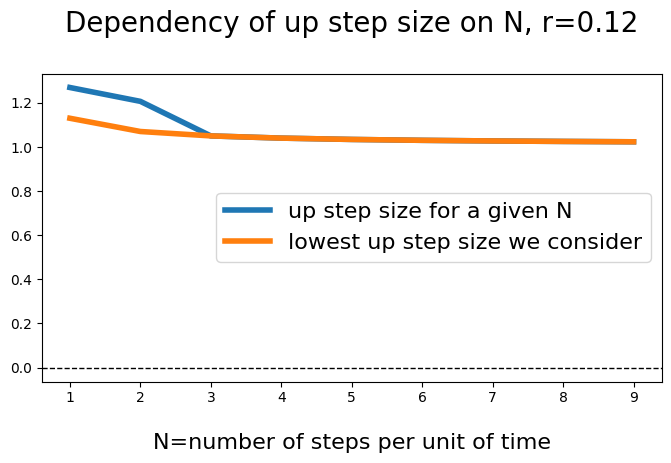

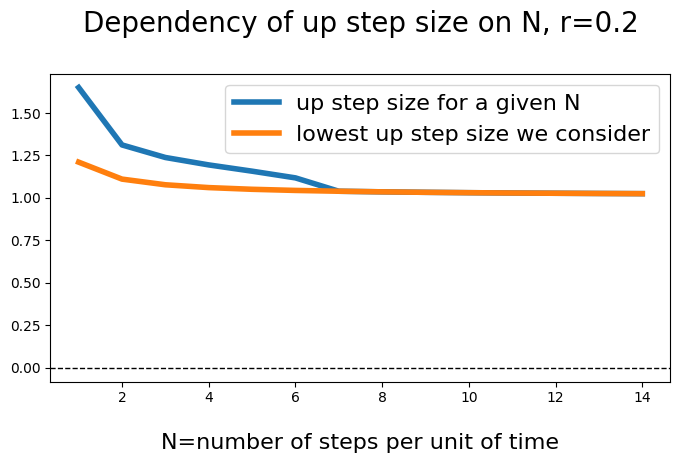

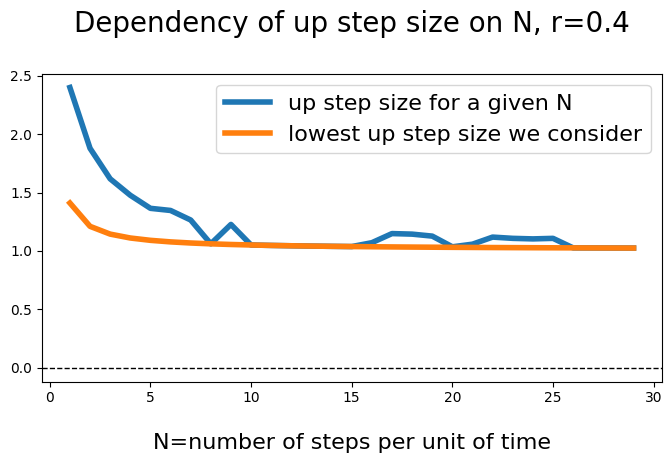

In [25]:
#dependency on the number of steps 
#Throughout this two implementation, the S0 will be supposed to be 1, as the formula for 'p_up' in the 'create_discounted_price_tree' algo was designed
#for this value of S0. For more general case, we should modify the definition of 'p_up' by replacing '1/discount_factor' by 'S0/discount_factor'.
import numpy as np

step_size = 1

r=0.12
N_values = np.arange(1, 10, step_size)
calibrate_the_u = np.array([calibrate(1.0, 3.0, N, 1000, 1.0, 0.1, r) for N in N_values])
lowest_u=np.array([1+r/N+0.01 for N in N_values]) #curve of the inf bound for the interval of up step size we are looking at.

layout = {'title': 'Dependency of up step size on N, r=0.12', 'x_label': 'N=number of steps per unit of time'}
my_plotter(N_values, [calibrate_the_u, lowest_u], layout=layout, names=['up step size for a given N', 'lowest up step size we consider'])

r=0.2
N_values = np.arange(1, 15, step_size)
calibrate_the_u = np.array([calibrate(1.0, 3.0, N, 1000, 1.0, 0.1, r) for N in N_values])
lowest_u=np.array([1+r/N+0.01 for N in N_values])

layout = {'title': 'Dependency of up step size on N, r=0.2', 'x_label': 'N=number of steps per unit of time'}
my_plotter(N_values, [calibrate_the_u, lowest_u], layout=layout, names=['up step size for a given N', 'lowest up step size we consider'])

r=0.4
N_values = np.arange(1, 30, step_size)
calibrate_the_u = np.array([calibrate(1.0, 3.0, N, 1000, 1.0, 0.1, r) for N in N_values])
lowest_u=np.array([1+r/N+0.01 for N in N_values])

layout = {'title': 'Dependency of up step size on N, r=0.4', 'x_label': 'N=number of steps per unit of time'}
my_plotter(N_values, [calibrate_the_u, lowest_u], layout=layout, names=['up step size for a given N', 'lowest up step size we consider'])

#In all cases, the up step size to be used to find the Balanced Binomial Tree that gives the price of an European call option, will get close to the
#lower bound of its possible values, approximately 1+r/N, when N is enough large. This convergence appears quickly, but is slower for higher values
#of r. It can be explained as, for an higher number of steps where each time we choose an up or a down step, we will tend to find as much up and down, 
#and as the tree is balanced (i.e. 1/2(u+d)=discount_factor), then we tend to see steps of size 1+r/N. And a larger r amplify the up step size, it
#then needs a higher number of steps to make the cases when we are more ups than downs less possible, and so the convergence is slower. 

In [23]:
N=1
K_values = [0.8, 0.9, 1.0, 1.1, 1.2]
T_values = [1, 2, 3, 4, 5]
r=0.2

for T in T_values:
    row = []
    for K in K_values:
        u = calibrate(K, T, N, 1000, 1.0, 0.1, r)
        u = '%.3f' % u
        row.append(u)
    print('T=',T,':')
    print(row)
print(1+r/N+0.01)

#The up step size we found tends to decrease to its lower bound 1+r when K tends to be bigger and it goes faster for T smaller. When K is bigger, the
#price of the European call option will decrease (thanks to its formula max(ST-K,0)) so the up step size to have the Binomial Branching Tree 
#corresponding to this price will have to decrease. For higher T, the price of the European call option will increase (thanks to its formula again), 
#so up step size of the Binomial Branching Tree corresponding to this price will have to be higher.  


T= 1 :
['1.647', '1.551', '1.455', '1.367', '1.321']
T= 2 :
['1.628', '1.559', '1.399', '1.292', '1.438']
T= 3 :
['1.764', '1.706', '1.644', '1.594', '1.536']
T= 4 :
['1.785', '1.769', '1.705', '1.639', '1.620']
T= 5 :
['1.893', '1.818', '1.795', '1.754', '1.706']
1.21
